# Test Lagged Features

Test whether previous month's delay rate helps predict current month's delay rate.

**Hypothesis:** Delays exhibit temporal autocorrelation - airlines with delays last month likely have delays this month (operational issues persist, seasonal patterns, etc.)

**Features to test:**
- `delay_rate_lag1`: Previous month's delay rate (same airline-route)
- `delay_rate_lag2`: 2 months ago
- `delay_rate_lag3`: 3 months ago
- Rolling averages (3-month, 6-month)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv('../data/processed/ml_training_data_syd_mel.csv')

# Parse dates
df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = pd.to_datetime(df['month']).dt.month
df['year'] = df['year'].astype(int)

# Create unique identifier for each airline-route combination
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']

print(f"Shape: {df.shape}")
print(f"Unique airline-routes: {df['airline_route'].nunique()}")

Shape: (1468, 59)
Unique airline-routes: 14


In [3]:
# Sort by airline-route and date for proper lag creation
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)
df.head(10)

,departing_port,arriving_port,airline,month,year_month,year,sectors_scheduled,sectors_flown,arrivals_on_time,arrivals_delayed,...,max_temperature_arr,max_wind_speed_arr,min_temperature_arr,rainy_days_arr,temp_range_mean_arr,temp_volatility_arr,wind_speed_std_arr,year_month_dt,month_num,airline_route
0,Melbourne,Sydney,Jetstar,2010-01-01,2010-01,2010,150.0,147.0,110.0,37.0,...,42.5,9.50,15.6,8.0,7.370968,3.963333,1.468147,2010-01-01,1,Jetstar_Melbourne_Sydney
1,Melbourne,Sydney,Jetstar,2010-02-01,2010-02,2010,136.0,132.0,91.0,41.0,...,38.6,12.10,18.6,12.0,6.910714,3.459259,1.880267,2010-02-01,2,Jetstar_Melbourne_Sydney
2,Melbourne,Sydney,Jetstar,2010-03-01,2010-03,2010,151.0,143.0,95.0,48.0,...,36.3,10.10,15.2,8.0,7.312903,3.230000,1.818019,2010-03-01,3,Jetstar_Melbourne_Sydney
3,Melbourne,Sydney,Jetstar,2010-04-01,2010-04,2010,145.0,142.0,109.0,33.0,...,30.2,6.89,11.0,10.0,8.480000,2.520690,1.215302,2010-04-01,4,Jetstar_Melbourne_Sydney
4,Melbourne,Sydney,Jetstar,2010-05-01,2010-05,2010,154.0,152.0,124.0,28.0,...,27.2,9.79,7.9,15.0,8.535484,1.983333,1.787585,2010-05-01,5,Jetstar_Melbourne_Sydney
5,Melbourne,Sydney,Jetstar,2010-06-01,2010-06,2010,150.0,149.0,110.0,39.0,...,19.9,8.98,3.2,14.0,8.100000,1.503448,1.611996,2010-06-01,6,Jetstar_Melbourne_Sydney
6,Melbourne,Sydney,Jetstar,2010-07-01,2010-07,2010,155.0,151.0,113.0,38.0,...,22.7,7.96,6.1,17.0,7.674194,1.520000,1.444918,2010-07-01,7,Jetstar_Melbourne_Sydney
7,Melbourne,Sydney,Jetstar,2010-08-01,2010-08,2010,154.0,154.0,123.0,31.0,...,25.4,13.35,6.0,5.0,9.087097,2.450000,2.159839,2010-08-01,8,Jetstar_Melbourne_Sydney
8,Melbourne,Sydney,Jetstar,2010-09-01,2010-09,2010,150.0,142.0,113.0,29.0,...,28.2,10.89,7.5,9.0,9.146667,3.382759,1.703346,2010-09-01,9,Jetstar_Melbourne_Sydney
9,Melbourne,Sydney,Jetstar,2010-10-01,2010-10,2010,157.0,144.0,98.0,46.0,...,30.6,11.49,9.7,15.0,7.848387,3.003333,1.891937,2010-10-01,10,Jetstar_Melbourne_Sydney


## 2. Create Lagged Features

In [4]:
# Create lagged features within each airline-route group
for lag in [1, 2, 3]:
    df[f'delay_rate_lag{lag}'] = df.groupby('airline_route')['delay_rate'].shift(lag)

# Rolling averages
df['delay_rate_rolling3'] = df.groupby('airline_route')['delay_rate'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)
df['delay_rate_rolling6'] = df.groupby('airline_route')['delay_rate'].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).mean()
)

print("Lagged features created:")
print(df[['airline_route', 'year_month', 'delay_rate', 'delay_rate_lag1', 
          'delay_rate_lag2', 'delay_rate_rolling3']].head(15))

Lagged features created:
               airline_route year_month  delay_rate  delay_rate_lag1  \
0   Jetstar_Melbourne_Sydney    2010-01    0.251701              NaN   
1   Jetstar_Melbourne_Sydney    2010-02    0.310606         0.251701   
2   Jetstar_Melbourne_Sydney    2010-03    0.335664         0.310606   
3   Jetstar_Melbourne_Sydney    2010-04    0.232394         0.335664   
4   Jetstar_Melbourne_Sydney    2010-05    0.184211         0.232394   
5   Jetstar_Melbourne_Sydney    2010-06    0.261745         0.184211   
6   Jetstar_Melbourne_Sydney    2010-07    0.251656         0.261745   
7   Jetstar_Melbourne_Sydney    2010-08    0.201299         0.251656   
8   Jetstar_Melbourne_Sydney    2010-09    0.204225         0.201299   
9   Jetstar_Melbourne_Sydney    2010-10    0.319444         0.204225   
10  Jetstar_Melbourne_Sydney    2010-11    0.337349         0.319444   
11  Jetstar_Melbourne_Sydney    2010-12    0.407609         0.337349   
12  Jetstar_Melbourne_Sydney    2011-01

In [5]:
# Check missing values (first few months will have NaN for lags)
lag_cols = ['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_lag3', 
            'delay_rate_rolling3', 'delay_rate_rolling6']
print("Missing values in lagged features:")
print(df[lag_cols].isnull().sum())

Missing values in lagged features:
delay_rate_lag1        14
delay_rate_lag2        28
delay_rate_lag3        42
delay_rate_rolling3    14
delay_rate_rolling6    14
dtype: int64


In [6]:
# Drop rows with missing lag values
df_clean = df.dropna(subset=['delay_rate_lag1']).copy()
print(f"Rows after dropping NaN: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

Rows after dropping NaN: 1454 (dropped 14)


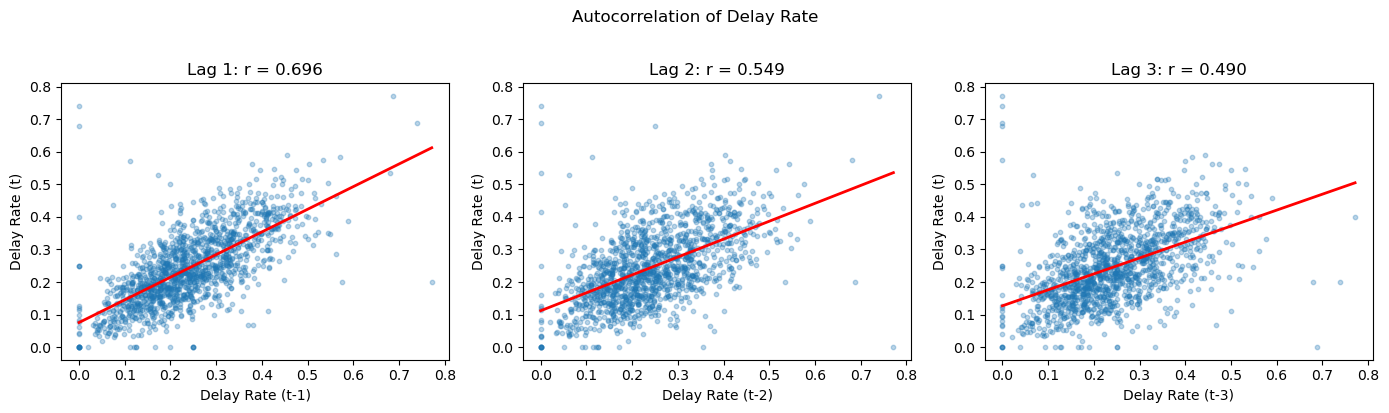

In [7]:
# Visualize autocorrelation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, lag in enumerate([1, 2, 3]):
    col = f'delay_rate_lag{lag}'
    ax = axes[i]
    
    # Drop NaN values for this specific lag
    mask = df_clean[col].notna() & df_clean['delay_rate'].notna()
    x_data = df_clean.loc[mask, col].values
    y_data = df_clean.loc[mask, 'delay_rate'].values
    
    ax.scatter(x_data, y_data, alpha=0.3, s=10)
    
    # Trend line - use only valid data
    if len(x_data) > 2:
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_data.min(), x_data.max(), 100)
        ax.plot(x_line, p(x_line), 'r-', linewidth=2)
    
    r = np.corrcoef(x_data, y_data)[0, 1]
    ax.set_xlabel(f'Delay Rate (t-{lag})')
    ax.set_ylabel('Delay Rate (t)')
    ax.set_title(f'Lag {lag}: r = {r:.3f}')

plt.suptitle('Autocorrelation of Delay Rate', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Correlation of lagged features with target
print("Correlation with delay_rate:")
print("=" * 40)
for col in lag_cols:
    r = df_clean[col].corr(df_clean['delay_rate'])
    print(f"  {col:<25}: {r:.4f}")

Correlation with delay_rate:
  delay_rate_lag1          : 0.6956
  delay_rate_lag2          : 0.5493
  delay_rate_lag3          : 0.4899
  delay_rate_rolling3      : 0.6640
  delay_rate_rolling6      : 0.6039


In [9]:
# Prepare features
# Cyclical month encoding
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month_num'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month_num'] / 12)

# One-hot encode airline
airline_dummies = pd.get_dummies(df_clean['airline'], prefix='airline')
df_clean = pd.concat([df_clean, airline_dummies], axis=1)

# Get only the one-hot encoded columns (not airline_route)
airline_cols = [c for c in airline_dummies.columns]
print(f"Airline columns: {airline_cols}")

Airline columns: ['airline_Jetstar', 'airline_Qantas', 'airline_QantasLink', 'airline_Regional Express', 'airline_Rex Airlines', 'airline_Tigerair Australia', 'airline_Virgin Australia']


## 4. Model Comparison

In [10]:
# Prepare features
# Cyclical month encoding
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month_num'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month_num'] / 12)

# One-hot encode airline
airline_dummies = pd.get_dummies(df_clean['airline'], prefix='airline')
df_clean = pd.concat([df_clean, airline_dummies], axis=1)

# Get only the one-hot encoded columns (not airline_route)
airline_cols = [c for c in airline_dummies.columns]
print(f"Airline columns: {airline_cols}")

Airline columns: ['airline_Jetstar', 'airline_Qantas', 'airline_QantasLink', 'airline_Regional Express', 'airline_Rex Airlines', 'airline_Tigerair Australia', 'airline_Virgin Australia']


In [11]:
# Define feature sets
baseline_features = airline_cols + ['month_sin', 'month_cos']
lag1_features = baseline_features + ['delay_rate_lag1']
all_lag_features = baseline_features + ['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_lag3',
                                         'delay_rate_rolling3', 'delay_rate_rolling6']

print(f"Baseline features: {len(baseline_features)}")
print(f"With lag1: {len(lag1_features)}")
print(f"All lags: {len(all_lag_features)}")

Baseline features: 9
With lag1: 10
All lags: 14


In [12]:
# Time-based split
train_mask = df_clean['year'] <= 2022
val_mask = df_clean['year'] == 2023
test_mask = df_clean['year'] >= 2024

print(f"Train (2010-2022): {train_mask.sum()} samples")
print(f"Validation (2023): {val_mask.sum()} samples")
print(f"Test (2024-2025):  {test_mask.sum()} samples")

Train (2010-2022): 1192 samples
Validation (2023): 100 samples
Test (2024-2025):  162 samples


In [13]:
# Prepare data for each feature set
def prepare_data(features):
    # Remove rows with NaN in selected features
    mask = df_clean[features].notna().all(axis=1)
    df_subset = df_clean[mask]
    
    train = df_subset[df_subset['year'] <= 2022]
    val = df_subset[df_subset['year'] == 2023]
    test = df_subset[df_subset['year'] >= 2024]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[features])
    X_val = scaler.transform(val[features])
    X_test = scaler.transform(test[features])
    
    return (X_train, train['delay_rate'].values, train['is_high_delay'].values,
            X_val, val['delay_rate'].values, val['is_high_delay'].values,
            X_test, test['delay_rate'].values, test['is_high_delay'].values)

In [14]:
def evaluate_model(features, name):
    """Train and evaluate regression model."""
    X_train, y_train_reg, y_train_clf, X_val, y_val_reg, y_val_clf, X_test, y_test_reg, y_test_clf = prepare_data(features)
    
    # Ridge regression
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train_reg)
    
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    results = {
        'name': name,
        'val_rmse': np.sqrt(mean_squared_error(y_val_reg, y_val_pred)),
        'val_r2': r2_score(y_val_reg, y_val_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test_reg, y_test_pred)),
        'test_r2': r2_score(y_test_reg, y_test_pred),
    }
    
    # Classification
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    clf.fit(X_train, y_train_clf)
    
    y_test_pred_clf = clf.predict(X_test)
    y_test_proba_clf = clf.predict_proba(X_test)[:, 1]
    
    results['test_f1'] = f1_score(y_test_clf, y_test_pred_clf)
    results['test_auc'] = roc_auc_score(y_test_clf, y_test_proba_clf)
    
    return results

In [15]:
# Evaluate all feature sets
results = []
results.append(evaluate_model(baseline_features, 'Baseline (airline+month)'))
results.append(evaluate_model(lag1_features, 'Baseline + Lag1'))
results.append(evaluate_model(all_lag_features, 'Baseline + All Lags'))

# Also test lag-only model
results.append(evaluate_model(['delay_rate_lag1'], 'Lag1 Only'))

results_df = pd.DataFrame(results)
results_df

,name,val_rmse,val_r2,test_rmse,test_r2,test_f1,test_auc
0,Baseline (airline+month),0.130734,-0.966420,0.092044,-0.214164,0.344828,0.703144
1,Baseline + Lag1,0.098079,-0.106772,0.079787,0.087673,0.625000,0.758165
2,Baseline + All Lags,0.108536,-0.355334,0.079698,0.089719,0.700637,0.740690
3,Lag1 Only,0.093288,-0.001285,0.081993,0.036540,0.644295,0.725885


In [16]:
# Display comparison
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"\n{'Model':<30} {'Val R²':>10} {'Test R²':>10} {'Test F1':>10} {'Test AUC':>10}")
print("-" * 80)

for _, row in results_df.iterrows():
    print(f"{row['name']:<30} {row['val_r2']:>10.4f} {row['test_r2']:>10.4f} {row['test_f1']:>10.4f} {row['test_auc']:>10.4f}")

MODEL COMPARISON

Model                              Val R²    Test R²    Test F1   Test AUC
--------------------------------------------------------------------------------
Baseline (airline+month)          -0.9664    -0.2142     0.3448     0.7031
Baseline + Lag1                   -0.1068     0.0877     0.6250     0.7582
Baseline + All Lags               -0.3553     0.0897     0.7006     0.7407
Lag1 Only                         -0.0013     0.0365     0.6443     0.7259


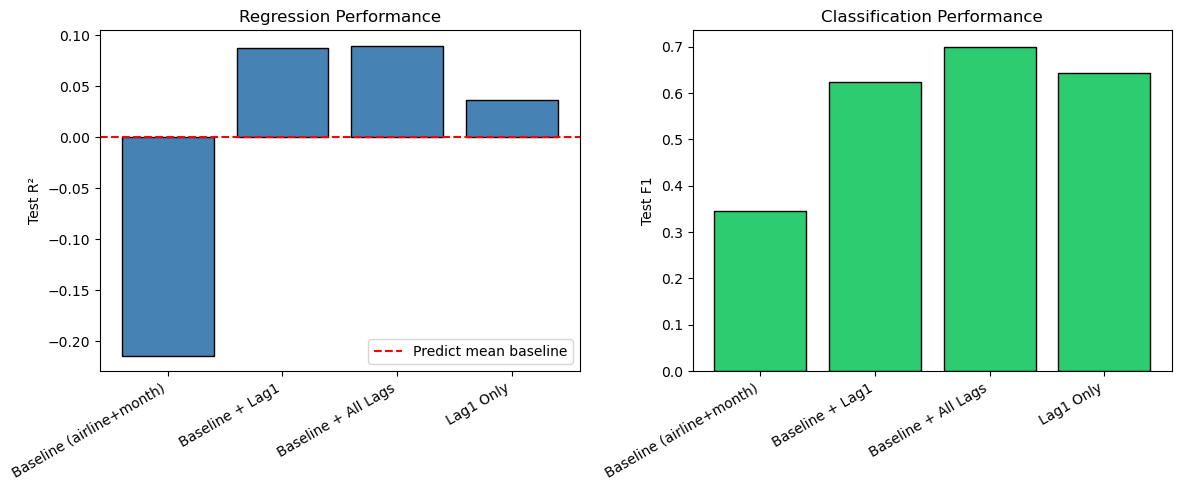

In [17]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² comparison
ax = axes[0]
x = range(len(results_df))
ax.bar(x, results_df['test_r2'], color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(results_df['name'], rotation=30, ha='right')
ax.set_ylabel('Test R²')
ax.set_title('Regression Performance')
ax.axhline(0, color='red', linestyle='--', label='Predict mean baseline')
ax.legend()

# F1 comparison
ax = axes[1]
ax.bar(x, results_df['test_f1'], color='#2ecc71', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(results_df['name'], rotation=30, ha='right')
ax.set_ylabel('Test F1')
ax.set_title('Classification Performance')

plt.tight_layout()
plt.show()

## 5. Summary

In [18]:
# Calculate improvement
baseline_r2 = results_df[results_df['name'] == 'Baseline (airline+month)']['test_r2'].values[0]
lag1_r2 = results_df[results_df['name'] == 'Baseline + Lag1']['test_r2'].values[0]
all_lag_r2 = results_df[results_df['name'] == 'Baseline + All Lags']['test_r2'].values[0]

baseline_f1 = results_df[results_df['name'] == 'Baseline (airline+month)']['test_f1'].values[0]
lag1_f1 = results_df[results_df['name'] == 'Baseline + Lag1']['test_f1'].values[0]
all_lag_f1 = results_df[results_df['name'] == 'Baseline + All Lags']['test_f1'].values[0]

print("=" * 70)
print("SUMMARY: LAGGED FEATURES IMPACT")
print("=" * 70)

print(f"\nREGRESSION (R²):")
print(f"  Baseline:           {baseline_r2:+.4f}")
print(f"  + Lag1:             {lag1_r2:+.4f} (improvement: {lag1_r2 - baseline_r2:+.4f})")
print(f"  + All Lags:         {all_lag_r2:+.4f} (improvement: {all_lag_r2 - baseline_r2:+.4f})")

print(f"\nCLASSIFICATION (F1):")
print(f"  Baseline:           {baseline_f1:.4f}")
print(f"  + Lag1:             {lag1_f1:.4f} (improvement: {lag1_f1 - baseline_f1:+.4f})")
print(f"  + All Lags:         {all_lag_f1:.4f} (improvement: {all_lag_f1 - baseline_f1:+.4f})")

print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)

if lag1_r2 > 0.1:
    print("\n✓ LAGGED FEATURES HELP SIGNIFICANTLY")
    print("  Previous month's delay rate is a strong predictor.")
    print("  Consider building a forecasting model with lagged features.")
elif lag1_r2 > baseline_r2 + 0.1:
    print("\n⚡ LAGGED FEATURES PROVIDE MODERATE IMPROVEMENT")
    print("  Some predictive value, but still limited.")
else:
    print("\n⚠️ LAGGED FEATURES DON'T HELP MUCH")
    print("  Delay rates may be too volatile to predict even with history.")

SUMMARY: LAGGED FEATURES IMPACT

REGRESSION (R²):
  Baseline:           -0.2142
  + Lag1:             +0.0877 (improvement: +0.3018)
  + All Lags:         +0.0897 (improvement: +0.3039)

CLASSIFICATION (F1):
  Baseline:           0.3448
  + Lag1:             0.6250 (improvement: +0.2802)
  + All Lags:         0.7006 (improvement: +0.3558)

VERDICT

⚡ LAGGED FEATURES PROVIDE MODERATE IMPROVEMENT
  Some predictive value, but still limited.


### Interpretation

**If lagged features help (R² > 0.1):**
- Delays have temporal persistence (operational issues carry over)
- A forecasting model using recent history is viable
- Consider ARIMA or similar time series approaches

**If lagged features don't help:**
- Delays are essentially random month-to-month
- No available features can reliably predict them
- Consider accepting this limitation or finding new data sources